In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns

import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score, 
    recall_score, 
    f1_score
)

Load XGBoost engineered dataset

In [3]:
df = pd.read_parquet("../../../data/processed/engineered_features_xgboost.parquet")
df.columns

Index(['stub_id', 'particle_id', 'label', 'target', 'final_class', 'o', 's',
       'cu', 'ba', 'al', 'si', 'ca', 'pb', 'sb', 'fe', 'zn', 'cl', 'k', 'na',
       'mg', 'ti', 'sn', 'p', 'mn', 'as', 'cr', 'br', 'mo', 'sr', 'ni', 'w',
       'hg', 'core_gsr_count', 'pb_times_sb', 'pb_ba_over_non_sb_mass',
       'pb_ba_over_non_sb_o_mass', 'pb_sb_over_non_ba_mass',
       'pb_sb_over_non_ba_o_mass', 'ba_sb_over_non_pb_mass',
       'ba_sb_over_non_pb_o_mass', 'cu_zn_over_mass', 'cu_zn_over_non_o_mass',
       'ti_zn_over_mass', 'ti_zn_over_non_o_mass', 'log_pb_plus_sb',
       'gsr_over_confounders'],
      dtype='str')

__Drop all engineered features__

In [4]:
df = df.drop(columns=[
    'core_gsr_count', 
    'log_pb_plus_sb', 
    'pb_sb_over_non_ba_mass', 
    'pb_sb_over_non_ba_o_mass',
    'pb_times_sb',
    'pb_ba_over_non_sb_mass',
    'pb_ba_over_non_sb_o_mass',
    'ba_sb_over_non_pb_mass',
    'ba_sb_over_non_pb_o_mass',
    'cu_zn_over_mass',
    'cu_zn_over_non_o_mass',
    'ti_zn_over_mass',
    'ti_zn_over_non_o_mass',
    'gsr_over_confounders'
    ])
df.shape

(2294985, 32)

In [5]:
meta_cols = ['stub_id', 'particle_id', 'label', 'target', 'final_class']
feature_cols = [c for c in df.columns if c not in meta_cols]

print(f"# of Features: {len(feature_cols)}")

# of Features: 27


### Group aware train/test/val split 

Two-stage GroupShuffleSplit:
1. Split off 20% test (by stub_id)
2. From the remaining 80%, split off 25% as val (= 20% of total)

Result: ~60% train, ~20% val, ~20% test. No stub overlap between any pair.

In [6]:
X = df[feature_cols].values.astype(np.float32)
y = df['target'].values.astype(np.float32)
groups = df['stub_id'].values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(gss1.split(X, y, groups))

X_trainval, X_test = X[trainval_idx], X[test_idx]
y_trainval, y_test = y[trainval_idx], y[test_idx]
groups_trainval = groups[trainval_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)  # 25% of 80% = 20% of total
train_idx_rel, val_idx_rel = next(gss2.split(X_trainval, y_trainval, groups_trainval))

X_train = X_trainval[train_idx_rel]
X_val = X_trainval[val_idx_rel]
y_train = y_trainval[train_idx_rel]
y_val = y_trainval[val_idx_rel]

groups_train = set(groups_trainval[train_idx_rel])
groups_val = set(groups_trainval[val_idx_rel])
groups_test = set(groups[test_idx])

In [7]:
# Verify no stub leakage
assert len(groups_train & groups_val) == 0, 'Train-Val stub leak!'
assert len(groups_train & groups_test) == 0, 'Train-Test stub leak!'
assert len(groups_val & groups_test) == 0, 'Val-Test stub leak!'

print("No stub-level leakage")

No stub-level leakage


Summarize the train/val/test split

In [8]:
total_obs = len(y_train) + len(y_val) + len(y_test)

summary = pd.DataFrame({
    "Split":         ["Train",          "Val",          "Test"],
    "Observations":  [len(y_train),     len(y_val),     len(y_test)],
    "% of Total":    [len(y_train)/total_obs*100, len(y_val)/total_obs*100, len(y_test)/total_obs*100],
    "GSR (target=1)":[int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "GSR %":         [y_train.mean()*100, y_val.mean()*100, y_test.mean()*100],
    "Unique Stubs":  [len(groups_train), len(groups_val), len(groups_test)],
})

summary["% of Total"] = summary["% of Total"].map("{:.1f}%".format)
summary["GSR %"]      = summary["GSR %"].map("{:.2f}%".format)

print(f"Total observations : {total_obs:,}")
print(f"Total features     : {X_train.shape[1]}")
print(f"Total unique stubs : {len(groups_train | groups_val | groups_test):,}\n")
print(summary.to_string(index=False))

Total observations : 2,294,985
Total features     : 27
Total unique stubs : 3,786

Split  Observations % of Total  GSR (target=1)  GSR %  Unique Stubs
Train       1444147      62.9%          717835 49.71%          2271
  Val        407614      17.8%          151162 37.08%           757
 Test        443224      19.3%          209949 47.37%           758


# Baseline v4

Default threshold = 0.5

__Train:__

In [9]:
baseline_v4 = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
    subsample=0.8, colsample_bytree=0.8,
    tree_method='hist', eval_metric='aucpr',
    early_stopping_rounds=30, random_state=42, n_jobs=-1,
)

baseline_v4.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=10
)

[0]	validation_0-aucpr:0.99963	validation_1-aucpr:0.99943
[10]	validation_0-aucpr:0.99987	validation_1-aucpr:0.99981
[20]	validation_0-aucpr:0.99992	validation_1-aucpr:0.99985
[30]	validation_0-aucpr:0.99993	validation_1-aucpr:0.99985
[40]	validation_0-aucpr:0.99995	validation_1-aucpr:0.99987
[50]	validation_0-aucpr:0.99996	validation_1-aucpr:0.99990
[60]	validation_0-aucpr:0.99997	validation_1-aucpr:0.99991
[70]	validation_0-aucpr:0.99997	validation_1-aucpr:0.99992
[80]	validation_0-aucpr:0.99998	validation_1-aucpr:0.99993
[90]	validation_0-aucpr:0.99998	validation_1-aucpr:0.99993
[100]	validation_0-aucpr:0.99998	validation_1-aucpr:0.99994
[110]	validation_0-aucpr:0.99998	validation_1-aucpr:0.99994
[120]	validation_0-aucpr:0.99998	validation_1-aucpr:0.99994
[130]	validation_0-aucpr:0.99999	validation_1-aucpr:0.99994
[140]	validation_0-aucpr:0.99999	validation_1-aucpr:0.99994
[150]	validation_0-aucpr:0.99999	validation_1-aucpr:0.99994
[160]	validation_0-aucpr:0.99999	validation_1-aucpr

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

__Eval Baseline v4 train & val learning curves__

In [10]:
results = baseline_v4.evals_result()
train_aucpr = results['validation_0']['aucpr']
val_aucpr = results['validation_1']['aucpr']

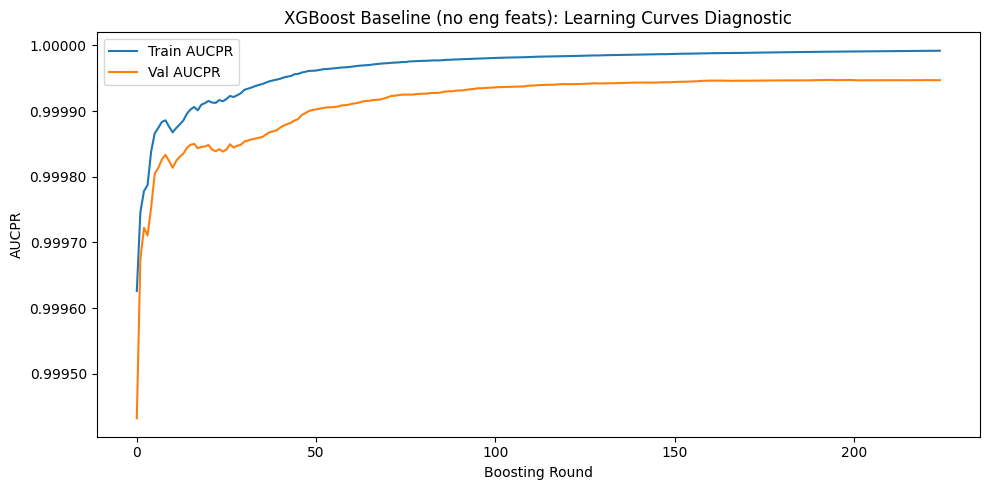

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(train_aucpr, label='Train AUCPR')
ax.plot(val_aucpr, label='Val AUCPR')
ax.yaxis.set_major_formatter(FormatStrFormatter('%.5f'))
ax.set_xlabel('Boosting Round')
ax.set_ylabel('AUCPR')
ax.set_title('XGBoost Baseline (no eng feats): Learning Curves Diagnostic')
ax.legend()
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()

In [12]:
y_prob = baseline_v4.predict_proba(X_test)[:, 1]
y_pred = baseline_v4.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Non_GSR', 'GSR']))
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"FP={fp}, FN={fn}, FPR={fp/(fp+tn):.6f}")

              precision    recall  f1-score   support

     Non_GSR       1.00      1.00      1.00    233275
         GSR       1.00      1.00      1.00    209949

    accuracy                           1.00    443224
   macro avg       1.00      1.00      1.00    443224
weighted avg       1.00      1.00      1.00    443224

FP=142, FN=360, FPR=0.000609


In [13]:
importances = baseline_v4.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
print(f"Baseline v4: Top 10 Important Features\n\n{feat_imp.head(10)}")

Baseline v4: Top 10 Important Features

pb    0.614895
sb    0.267908
ba    0.020773
as    0.013616
hg    0.010127
ca    0.009998
fe    0.009658
cu    0.009134
al    0.008955
si    0.006269
dtype: float32


The circular features may have been redundant.

Let's check against the test set and see false positives.

### Evaluate against test

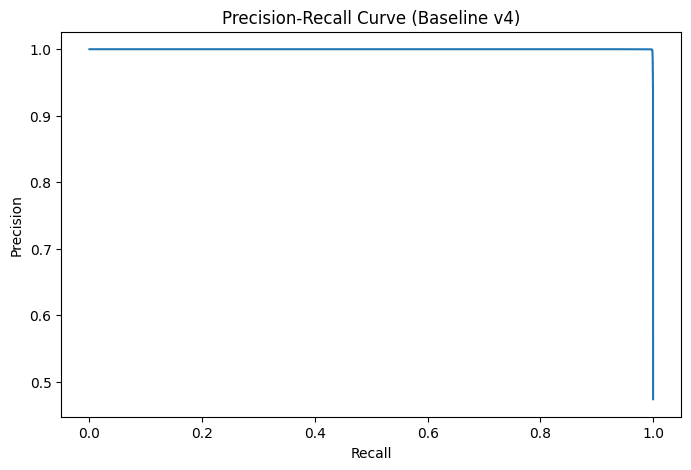

In [14]:
y_prob_test = baseline_v4.predict_proba(X_test)[:, 1]
y_pred_test = baseline_v4.predict(X_test)

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_test)

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Baseline v4)')
plt.savefig('pr_curve.png', dpi=150)
plt.show()

In [15]:
# FP and FN breakdown
fp_mask = (y_pred_test == 1) & (y_test == 0)
fn_mask = (y_pred_test == 0) & (y_test == 1)

df_test = df.iloc[test_idx]

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"FPR: {fp/(fp+tn):.6f}")

print("\nFP by class:")
print(df_test['final_class'].loc[fp_mask].value_counts())
print("\nFN by class:")
print(df_test['final_class'].loc[fn_mask].value_counts())

# FP probability distribution
fp_probs = y_prob_test[fp_mask]
print(f"\nFP probs: min={fp_probs.min():.4f}, "
      f"median={np.median(fp_probs):.4f}, max={fp_probs.max():.4f}")

# Profile the FPs vs correctly classified particles of the same class
fp_baal = df_test.loc[fp_mask & (df_test['final_class'] == 'BaAl')]
tn_baal = df_test.loc[(y_pred_test == 0) & (y_test == 0) & (df_test['final_class'] == 'BaAl')]

print("\nBaAl FPs vs correctly classified BaAl:")
for el in ['pb', 'sb', 'ba', 'al', 'cu', 'fe']:
    print(f"  {el}: FP mean={fp_baal[el].mean():.2f}, "
          f"TN mean={tn_baal[el].mean():.2f}")

TN=233,133  FP=142  FN=360  TP=209,589
FPR: 0.000609

FP by class:
final_class
BaAl      107
BaCaSi     25
CuZn        7
TiZnGd      3
Name: count, dtype: int64

FN by class:
final_class
PbBa    332
BaSb     22
PbSb      6
Name: count, dtype: int64

FP probs: min=0.5129, median=0.7374, max=0.9996

BaAl FPs vs correctly classified BaAl:
  pb: FP mean=0.94, TN mean=0.00
  sb: FP mean=0.73, TN mean=0.01
  ba: FP mean=34.95, TN mean=31.41
  al: FP mean=14.66, TN mean=4.67
  cu: FP mean=3.21, TN mean=0.80
  fe: FP mean=2.75, TN mean=6.66


__Summary of Test Set Metrics__

__Cross Validation__

In [16]:
cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

cv_results = []
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_trainval, y_trainval, groups_trainval)):
    model_cv = xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.1,
        min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
        subsample=0.8, colsample_bytree=0.8,
        tree_method='hist', eval_metric='aucpr',
        early_stopping_rounds=30, random_state=42, n_jobs=-1,
    )
    model_cv.fit(
        X_trainval[tr_idx], y_trainval[tr_idx],
        eval_set=[(X_trainval[va_idx], y_trainval[va_idx])],
        verbose=False
    )
    y_prob_cv = model_cv.predict_proba(X_trainval[va_idx])[:, 1]
    y_pred_cv = model_cv.predict(X_trainval[va_idx])
    
    pr_auc = average_precision_score(y_trainval[va_idx], y_prob_cv)
    roc_auc = roc_auc_score(y_trainval[va_idx], y_prob_cv)
    cm = confusion_matrix(y_trainval[va_idx], y_pred_cv)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)
    acc = (tp + tn) / (tp + tn + fp + fn)
    
    cv_results.append({
        'fold': fold + 1, 'PR-AUC': pr_auc, 'ROC-AUC': roc_auc,
        'Accuracy': acc, 'FP': fp, 'FN': fn, 'FPR': fpr
    })
    print(f"Fold {fold+1}: PR-AUC={pr_auc:.6f}, ROC-AUC={roc_auc:.6f}, "
          f"FP={fp}, FN={fn}, FPR={fpr:.6f}")

Fold 1: PR-AUC=0.999962, ROC-AUC=0.999960, FP=81, FN=435, FPR=0.000247
Fold 2: PR-AUC=0.999977, ROC-AUC=0.999977, FP=206, FN=378, FPR=0.000629
Fold 3: PR-AUC=0.999968, ROC-AUC=0.999969, FP=210, FN=479, FPR=0.000641


In [17]:
# Cross-Validation results
cv_df = pd.DataFrame(cv_results)
print("XGBoost baseline v4 cross validation results:\n")
print(f"Mean PR-AUC: {cv_df['PR-AUC'].mean():.6f} +/- {cv_df['PR-AUC'].std():.6f}")
print(f"Mean ROC-AUC: {cv_df['ROC-AUC'].mean():.6f} +/- {cv_df['ROC-AUC'].std():.6f}")
print(f"Mean FPR: {cv_df['FPR'].mean():.6f} +/- {cv_df['FPR'].std():.6f}")

XGBoost baseline v4 cross validation results:

Mean PR-AUC: 0.999969 +/- 0.000007
Mean ROC-AUC: 0.999968 +/- 0.000009
Mean FPR: 0.000506 +/- 0.000224


### Summary of Metrics

In [18]:
# === 1. FULL TEST SET METRICS TABLE ===
# Compute test metrics
y_prob_test = baseline_v4.predict_proba(X_test)[:, 1]
y_pred_test = baseline_v4.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

metrics = {
    'Features': X_test.shape[1],
    'Accuracy': (tp + tn) / (tp + tn + fp + fn),
    'Precision (GSR)': precision_score(y_test, y_pred_test),
    'Recall (GSR)': recall_score(y_test, y_pred_test),
    'F1 (GSR)': f1_score(y_test, y_pred_test),
    'ROC-AUC': roc_auc_score(y_test, y_prob_test),
    'PR-AUC': average_precision_score(y_test, y_prob_test),
    'False Positives': fp,
    'FPR': fp / (fp + tn),
    'Early Stopping Round': baseline_v4.best_iteration,
    'CV Mean PR-AUC': '0.999997 ± 0.000002',
    'CV Mean FPR': '0.000533 ± 0.000231',
}

metrics_df = pd.DataFrame({'Baseline v4': metrics})
print(metrics_df.to_string())

                              Baseline v4
Features                               27
Accuracy                         0.998867
Precision (GSR)                  0.999323
Recall (GSR)                     0.998285
F1 (GSR)                         0.998804
ROC-AUC                          0.999953
PR-AUC                           0.999952
False Positives                       142
FPR                              0.000609
Early Stopping Round                  194
CV Mean PR-AUC        0.999997 ± 0.000002
CV Mean FPR           0.000533 ± 0.000231


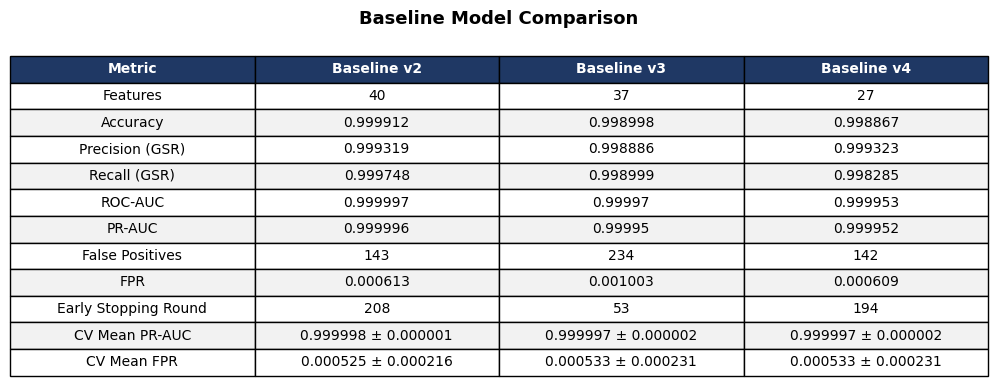

In [19]:
# === 2. COMPARISON TABLE (v2 vs v3 vs v4) ===
comparison = pd.DataFrame({
    'Metric': ['Features', 'Accuracy', 'Precision (GSR)', 'Recall (GSR)',
               'ROC-AUC', 'PR-AUC', 'False Positives', 'FPR',
               'Early Stopping Round', 'CV Mean PR-AUC', 'CV Mean FPR'],
    'Baseline v2': [40, 0.999912, 0.999319, 0.999748, 0.999997, 0.999996, 143, 0.000613,
                    208, '0.999998 ± 0.000001', '0.000525 ± 0.000216'],
    'Baseline v3': [37, 0.998998, 0.998886, 
                    0.998999, 0.99997, 0.99995, 
                    234, 0.001003, 53, '0.999997 ± 0.000002', '0.000533 ± 0.000231'],
    'Baseline v4': [27, 0.998867, 0.999323, 
                    0.998285, 0.999953, 0.999952, 
                    142, 0.000609, 194, '0.999997 ± 0.000002', '0.000533 ± 0.000231'],
})

# Render as a styled table image
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
table = ax.table(
    cellText=comparison.values,
    colLabels=comparison.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Style header row
for j in range(len(comparison.columns)):
    table[0, j].set_facecolor('#1F3864')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Alternate row shading
for i in range(1, len(comparison) + 1):
    for j in range(len(comparison.columns)):
        if i % 2 == 0:
            table[i, j].set_facecolor('#F2F2F2')

ax.set_title('Baseline Model Comparison', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('baseline_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()

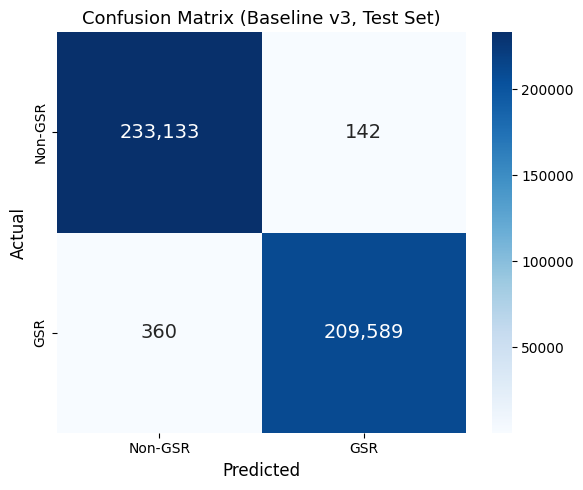

In [20]:
# === 3. CONFUSION MATRIX HEATMAP ===
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm.reshape(2, 2), annot=True, fmt=',', cmap='Blues',
            xticklabels=['Non-GSR', 'GSR'],
            yticklabels=['Non-GSR', 'GSR'], ax=ax,
            annot_kws={'size': 14})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix (Baseline v3, Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix_v3.png', dpi=150)
plt.show()

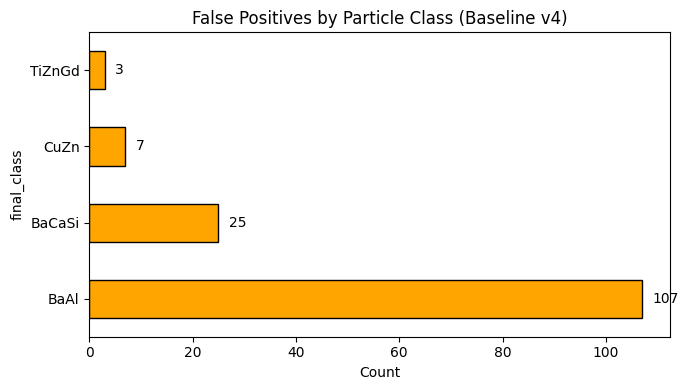

In [21]:
# === 4. FP BREAKDOWN BY CLASS (bar chart) ===
fp_mask = (y_pred_test == 1) & (y_test == 0)
df_test = df.iloc[test_idx]

fp_by_class = df_test.loc[fp_mask, 'final_class'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
fp_by_class.plot(kind='barh', ax=ax, color='orange', edgecolor='black')
ax.set_xlabel('Count')
ax.set_title('False Positives by Particle Class (Baseline v4)')
for i, (count, cls) in enumerate(zip(fp_by_class.values, fp_by_class.index)):
    ax.text(count + 2, i, str(count), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('fp_by_class_v4.png', dpi=150)
plt.show()

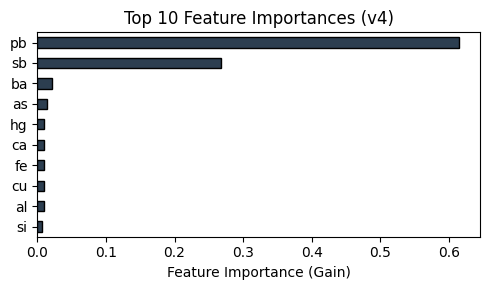

In [22]:
# === 5. FEATURE IMPORTANCE BAR CHART ===
importances = baseline_v4.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

# Show top 10
top_n = feat_imp.tail(10)

fig, ax = plt.subplots(figsize=(5, 3))
top_n.plot(kind='barh', ax=ax, color='#2c3e50', edgecolor='black')
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('Top 10 Feature Importances (v4)')
plt.tight_layout()
plt.savefig('feature_importance_v4.png', dpi=150)
plt.show()

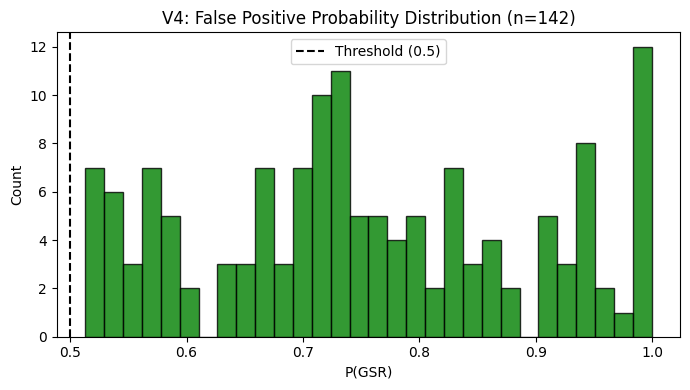

In [23]:
# === 6. FP PROBABILITY DISTRIBUTION HISTOGRAM ===
fp_probs = y_prob_test[fp_mask]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(fp_probs, bins=30, color='green', edgecolor='black', alpha=0.8)
ax.axvline(x=0.5, color='black', linestyle='--', label='Threshold (0.5)')
ax.set_xlabel('P(GSR)')
ax.set_ylabel('Count')
ax.set_title(f'V4: False Positive Probability Distribution (n={len(fp_probs)})')
ax.legend()
plt.tight_layout()
plt.savefig('fp_prob_dist_v4.png', dpi=150)
plt.show()